# Face Authentication — Testing & FastAPI Service


### 1. Imports

In [20]:
import io
import os
import cv2
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image
from torchvision import transforms
from facenet_pytorch import InceptionResnetV1
from typing import Dict, List, Tuple, Optional
import warnings
warnings.filterwarnings('ignore')

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {DEVICE}')

Using device: cpu


### 2. Model Architecture


In [21]:
class FaceEmbedder(nn.Module):
    """
    Identical architecture to face_auth_training.ipynb.
    Backbone: InceptionResnetV1 (random init here; weights loaded from checkpoint).
    Projection head: Linear -> LayerNorm -> ReLU -> Linear -> L2-normalise.
    """
    def __init__(self, embedding_dim: int = 512):
        super().__init__()
        # pretrained=None — no network call; weights come from checkpoint
        self.backbone = InceptionResnetV1(pretrained=None)
        self.projection = nn.Sequential(
            nn.Linear(512, embedding_dim),
            nn.LayerNorm(embedding_dim),   # safe for batch-size 1
            nn.ReLU(inplace=True),
            nn.Linear(embedding_dim, embedding_dim),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        emb = self.backbone(x)          # (B, 512)
        emb = self.projection(emb)      # (B, embedding_dim)
        return nn.functional.normalize(emb, p=2, dim=1)

print('FaceEmbedder class defined.')

FaceEmbedder class defined.


### 3. Face Detector (offline MTCNN)


In [22]:
# ── MTCNN weight cache paths (written by facenet-pytorch after first download) ──
_MTCNN_CACHE_DIR = os.path.join(os.path.expanduser('~'), '.cache', 'torch', 'checkpoints')
_MTCNN_NETS      = ['pnet.pt', 'rnet.pt', 'onet.pt']
_MTCNN_CACHED    = all(
    os.path.exists(os.path.join(_MTCNN_CACHE_DIR, w)) for w in _MTCNN_NETS
)

# ── OpenCV Haar cascade (offline fallback) ──────────────────────────────────
_HAAR_XML = cv2.data.haarcascades + 'haarcascade_frontalface_default.xml'
_haar_detector = cv2.CascadeClassifier(_HAAR_XML)


def _detect_faces_haar(pil_image: Image.Image):
    """
    Detect faces with OpenCV Haar cascade (no internet needed).
    Returns list of [x1, y1, x2, y2] boxes, largest face first.
    """
    img_bgr  = cv2.cvtColor(np.array(pil_image.convert('RGB')), cv2.COLOR_RGB2BGR)
    gray     = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
    faces    = _haar_detector.detectMultiScale(
        gray, scaleFactor=1.1, minNeighbors=5, minSize=(30, 30)
    )
    if len(faces) == 0:
        return []
    # Sort by area descending (largest = most prominent face first)
    faces = sorted(faces, key=lambda f: f[2]*f[3], reverse=True)
    return [[x, y, x+w, y+h] for x, y, w, h in faces]


def _detect_faces(pil_image: Image.Image, mtcnn_detector=None):
    """
    Unified detector: uses MTCNN if available and cached, else Haar.
    Returns [x1, y1, x2, y2] of the most prominent face, or None.
    """
    if mtcnn_detector is not None:
        try:
            boxes, _ = mtcnn_detector.detect(pil_image.convert('RGB'))
            if boxes is not None and len(boxes) > 0:
                return [int(v) for v in boxes[0]]
        except Exception:
            pass  # fall through to Haar

    boxes = _detect_faces_haar(pil_image)
    return boxes[0] if boxes else None


if _MTCNN_CACHED:
    from facenet_pytorch import MTCNN as _MTCNN
    _mtcnn = _MTCNN(keep_all=False, device=DEVICE,
                    min_face_size=20, post_process=False)
    print('Face detector : MTCNN (loaded from local cache)')
else:
    _mtcnn = None
    print('Face detector : OpenCV Haar cascade (offline fallback — MTCNN not cached)')

Face detector : OpenCV Haar cascade (offline fallback — MTCNN not cached)


### 4. `load_model()` — Load Trained Checkpoint

In [ ]:
# ── Global inference state ──────────────────────────────────────────────────
_model    : Optional[FaceEmbedder] = None
_threshold: float                  = 0.6
_transform = transforms.Compose([
    transforms.Resize((160, 160)),
    transforms.ToTensor(),
    transforms.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5]),
])


def load_model(checkpoint_path: str = './face_auth_model.pth') -> None:
    """
    Load FaceEmbedder weights from a checkpoint saved by face_auth_training.ipynb.

    Fixes vs original:
      - weights_only=False  → required; checkpoint contains non-tensor objects
      - Architecture matches training exactly (LayerNorm, two linear layers)
      - No network calls made anywhere in this function

    Args:
        checkpoint_path: path to .pth file produced by training notebook.
    """
    global _model, _threshold

    # Validate file exists before doing anything else
    if not os.path.exists(checkpoint_path):
        raise FileNotFoundError(
            f"Checkpoint not found: '{checkpoint_path}'.\n"
            "Run face_auth_training.ipynb first to generate it."
        )

  
    checkpoint = torch.load(
        checkpoint_path,
        map_location=DEVICE,
        weights_only=False,   # False required: checkpoint has non-tensor objects
    )

    cfg           = checkpoint.get('config', {})
    embedding_dim = cfg.get('embedding_dim', 512)

    # Build model with same architecture as training 
    _model = FaceEmbedder(embedding_dim=embedding_dim).to(DEVICE)

    # strict=False tolerates minor key mismatches (e.g. frozen backbone layers
    # stored without grad info); set strict=True to catch real mismatches.
    missing, unexpected = _model.load_state_dict(
        checkpoint['model_state'], strict=False
    )
    if missing:
        print(f'  [warn] Missing keys  : {missing[:5]}{'...' if len(missing)>5 else ""}')
    if unexpected:
        print(f'  [warn] Unexpected keys: {unexpected[:5]}{'...' if len(unexpected)>5 else ""}')

    _model.eval()   # inference mode — disables dropout, fixes LayerNorm

    _threshold = checkpoint.get('threshold', 0.6)

    print(f"Model loaded from '{checkpoint_path}'")
    print(f"  Epoch        : {checkpoint.get('epoch', '?')}")
    print(f"  Best loss    : {checkpoint.get('loss', '?')}")
    print(f"  Threshold    : {_threshold:.2f}")
    print(f"  Embedding dim: {embedding_dim}")
    print(f"  Device       : {DEVICE}")



load_model('./face_auth_model.pth')

Model loaded from './face_auth_model.pth'
  Epoch        : 17
  Best loss    : 0.007181034237146377
  Threshold    : 0.79
  Embedding dim: 512
  Device       : cpu


### 5. Helper — Detect Face & Extract Embedding

In [24]:
def _detect_and_embed(
    pil_image: Image.Image,
) -> Tuple[Optional[torch.Tensor], Optional[List[int]]]:
    """
    Detect the most prominent face, crop it, return (embedding, bbox).
    Returns (None, None) if no face is found.
    """
    if _model is None:
        raise RuntimeError('Model not loaded. Call load_model() first.')

    img_rgb = pil_image.convert('RGB')
    bbox    = _detect_faces(img_rgb, _mtcnn)   # [x1,y1,x2,y2] or None

    if bbox is None:
        return None, None

    x1, y1, x2, y2 = bbox
    # Clamp to image bounds
    w, h = img_rgb.size
    x1, y1 = max(0, x1), max(0, y1)
    x2, y2 = min(w, x2), min(h, y2)

    if x2 <= x1 or y2 <= y1:
        return None, None   # degenerate box

    face_crop = img_rgb.crop((x1, y1, x2, y2))
    tensor    = _transform(face_crop).unsqueeze(0).to(DEVICE)  # (1,3,160,160)

    with torch.no_grad():
        embedding = _model(tensor).squeeze(0)   # (embedding_dim,)

    return embedding, [x1, y1, x2, y2]

print('_detect_and_embed() ready.')

_detect_and_embed() ready.


### 6. `predict()` — Main Inference Function

In [25]:
def predict(
    image1    : Image.Image,
    image2    : Image.Image,
    threshold : Optional[float] = None,
) -> Dict:
    """
    Verify whether two face images belong to the same person.

    Args:
        image1    : PIL Image — first face
        image2    : PIL Image — second face
        threshold : override cosine similarity threshold (default: from checkpoint)

    Returns:
        {
          'verification_result' : 'same person' | 'different person' | 'face not detected in <img>',
          'similarity_score'    : float in [-1, 1]  (None if face missing),
          'bounding_boxes'      : {'image1': [x1,y1,x2,y2]|None, 'image2': ...},
          'threshold_used'      : float
        }
    """
    thresh = threshold if threshold is not None else _threshold

    emb1, bbox1 = _detect_and_embed(image1)
    emb2, bbox2 = _detect_and_embed(image2)

    if emb1 is None or emb2 is None:
        missing = []
        if emb1 is None: missing.append('image1')
        if emb2 is None: missing.append('image2')
        return {
            'verification_result': f"face not detected in {', '.join(missing)}",
            'similarity_score'   : None,
            'bounding_boxes'     : {'image1': bbox1, 'image2': bbox2},
            'threshold_used'     : thresh,
        }

    similarity = nn.functional.cosine_similarity(
        emb1.unsqueeze(0), emb2.unsqueeze(0)
    ).item()

    return {
        'verification_result': 'same person' if similarity >= thresh else 'different person',
        'similarity_score'   : round(similarity, 4),
        'bounding_boxes'     : {'image1': bbox1, 'image2': bbox2},
        'threshold_used'     : thresh,
    }

print('predict() ready.')

predict() ready.


### 7. Quick Local Test (user-input paths)


FACE VERIFICATION RESULT
  Verdict          : DIFFERENT PERSON
  Similarity Score : 0.6378
  Threshold Used   : 0.7900000000000005
  BBox Image 1     : [102, 24, 171, 93]
  BBox Image 2     : [187, 86, 394, 293]


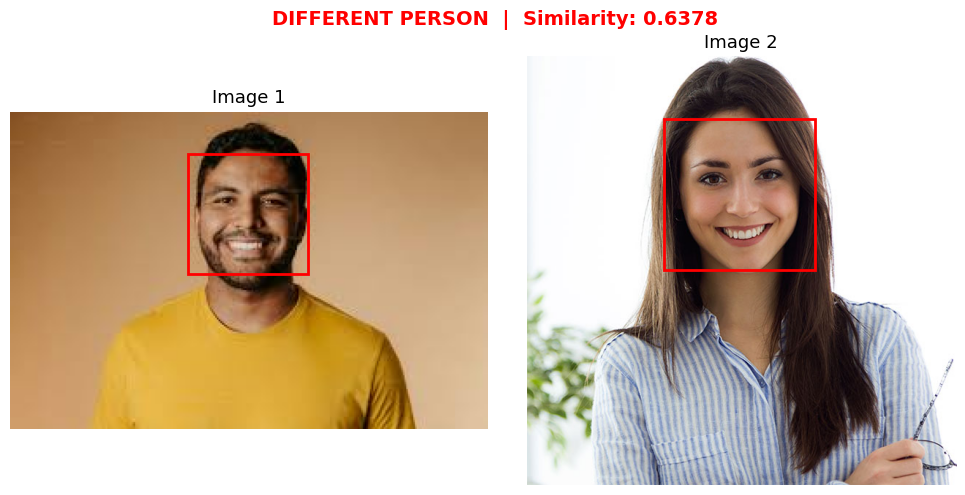

In [26]:
IMAGE_PATH_1 = input('Enter path to first face image : ').strip()
IMAGE_PATH_2 = input('Enter path to second face image: ').strip()

img1 = Image.open(IMAGE_PATH_1)
img2 = Image.open(IMAGE_PATH_2)

result = predict(img1, img2)

print('\n' + '='*50)
print('FACE VERIFICATION RESULT')
print('='*50)
print(f"  Verdict          : {result['verification_result'].upper()}")
print(f"  Similarity Score : {result['similarity_score']}")
print(f"  Threshold Used   : {result['threshold_used']}")
print(f"  BBox Image 1     : {result['bounding_boxes']['image1']}")
print(f"  BBox Image 2     : {result['bounding_boxes']['image2']}")
print('='*50)

# Visualise
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
color = 'lime' if result['verification_result'] == 'same person' else 'red'

for ax, img, bbox, title in zip(
    axes,
    [img1, img2],
    [result['bounding_boxes']['image1'], result['bounding_boxes']['image2']],
    ['Image 1', 'Image 2'],
):
    ax.imshow(img)
    ax.set_title(title, fontsize=13)
    ax.axis('off')
    if bbox:
        x1, y1, x2, y2 = bbox
        rect = patches.Rectangle(
            (x1, y1), x2-x1, y2-y1,
            linewidth=2, edgecolor=color, facecolor='none'
        )
        ax.add_patch(rect)

fig.suptitle(
    f"{result['verification_result'].upper()}  |  Similarity: {result['similarity_score']}",
    fontsize=14, color=color, fontweight='bold'
)
plt.tight_layout()
plt.show()

In [27]:
from fastapi import FastAPI, File, UploadFile, HTTPException, Query
from fastapi.responses import JSONResponse
from fastapi.middleware.cors import CORSMiddleware
import uvicorn
import nest_asyncio
import threading
import asyncio

nest_asyncio.apply()   # allows uvicorn to run inside Jupyter's event loop

app = FastAPI(
    title       = 'Face Authentication API',
    description = 'Verify whether two face images belong to the same person.',
    version     = '1.0.0',
)
app.add_middleware(
    CORSMiddleware,
    allow_origins=['*'], allow_methods=['*'], allow_headers=['*'],
)


@app.get('/health', tags=['Utilities'])
async def health_check():
    return {
        'status'   : 'ok',
        'model'    : 'loaded' if _model is not None else 'not loaded',
        'detector' : 'MTCNN' if _mtcnn is not None else 'Haar (offline)',
        'threshold': _threshold,
        'device'   : str(DEVICE),
    }


@app.post('/verify', tags=['Face Verification'])
async def verify_faces(
    image1    : UploadFile = File(..., description='First face image (JPEG/PNG)'),
    image2    : UploadFile = File(..., description='Second face image (JPEG/PNG)'),
    threshold : Optional[float] = Query(
        default=None, ge=0.0, le=1.0,
        description='Override similarity threshold'
    ),
):
    allowed = {'image/jpeg', 'image/jpg', 'image/png', 'image/webp'}
    for f, label in [(image1, 'image1'), (image2, 'image2')]:
        if f.content_type not in allowed:
            raise HTTPException(415, f'{label}: unsupported type {f.content_type!r}')

    try:
        pil1 = Image.open(io.BytesIO(await image1.read()))
        pil2 = Image.open(io.BytesIO(await image2.read()))
    except Exception as e:
        raise HTTPException(400, f'Could not decode images: {e}')

    try:
        result = predict(pil1, pil2, threshold=threshold)
    except RuntimeError as e:
        raise HTTPException(503, str(e))

    return JSONResponse(content=result)


# ── Run uvicorn in a background thread to avoid Jupyter event-loop conflict ──
_server_config = uvicorn.Config(app, host='0.0.0.0', port=8000, log_level='info')
_server        = uvicorn.Server(_server_config)

_server_thread = threading.Thread(target=_server.run, daemon=True)
_server_thread.start()

# Give the server a moment to start
import time; time.sleep(1)
print('✅ FastAPI server running at http://127.0.0.1:8000')
print('📖 Swagger UI  → http://127.0.0.1:8000/docs')
print('(Running in background thread — cell returns immediately)')


INFO:     Started server process [7028]
INFO:     Waiting for application startup.
INFO:     Application startup complete.
ERROR:    [Errno 10048] error while attempting to bind on address ('0.0.0.0', 8000): [winerror 10048] only one usage of each socket address (protocol/network address/port) is normally permitted
INFO:     Waiting for application shutdown.
INFO:     Application shutdown complete.


✅ FastAPI server running at http://127.0.0.1:8000
📖 Swagger UI  → http://127.0.0.1:8000/docs
(Running in background thread — cell returns immediately)


### 9. Test the API (run while server cell above is active)

In [ ]:
import requests, json, os

IMG1 = input('Path to face image 1: ').strip().strip('"')
IMG2 = input('Path to face image 2: ').strip().strip('"')

with open(IMG1, 'rb') as f1, open(IMG2, 'rb') as f2:
    response = requests.post(
        'http://127.0.0.1:8000/verify',
        files={
            'image1': (os.path.basename(IMG1), f1, 'image/jpeg'),
            'image2': (os.path.basename(IMG2), f2, 'image/jpeg'),
        }
    )

print(f'Status : {response.status_code}')

try:
    print(json.dumps(response.json(), indent=2))
except Exception:
    print("Server did not return JSON. Raw response:")
    print(response.text)


Status : 500
Server did not return JSON. Raw response:
Internal Server Error


"\nimport requests, json\n\nIMG1 = input('Path to face image 1: ').strip()\nIMG2 = input('Path to face image 2: ').strip()\n\nwith open(IMG1, 'rb') as f1, open(IMG2, 'rb') as f2:\n    response = requests.post(\n        'http://127.0.0.1:8000/verify',\n        files={\n            'image1': (IMG1, f1, 'image/jpeg'),\n            'image2': (IMG2, f2, 'image/jpeg'),\n        }\n    )\n\nprint(f'Status : {response.status_code}')\nprint(json.dumps(response.json(), indent=2))"